In [84]:
words = open('names.txt', 'r').read().splitlines()
print(words[:10])

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']


In [85]:
b = {}
print(set(''.join(words)))
chars = sorted(list(set(''.join(words))))
print(chars)

stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0

for w in words[:]:
    chs = ['.'] + list(w)+ ["."]
    for ch1,ch2 in zip(chs, chs[1:]):
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram,0)+1
sorted_b = sorted(b.items(), key = lambda kv: kv[1])
sorted_b.reverse()
print(sorted_b)
stoi

{'o', 'b', 'k', 'i', 's', 'j', 'd', 'y', 'w', 'q', 'a', 'e', 'c', 't', 'm', 'l', 'x', 'n', 'v', 'p', 'r', 'f', 'z', 'u', 'g', 'h'}
['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
[(('n', '.'), 6763), (('a', '.'), 6640), (('a', 'n'), 5438), (('.', 'a'), 4410), (('e', '.'), 3983), (('a', 'r'), 3264), (('e', 'l'), 3248), (('r', 'i'), 3033), (('n', 'a'), 2977), (('.', 'k'), 2963), (('l', 'e'), 2921), (('e', 'n'), 2675), (('l', 'a'), 2623), (('m', 'a'), 2590), (('.', 'm'), 2538), (('a', 'l'), 2528), (('i', '.'), 2489), (('l', 'i'), 2480), (('i', 'a'), 2445), (('.', 'j'), 2422), (('o', 'n'), 2411), (('h', '.'), 2409), (('r', 'a'), 2356), (('a', 'h'), 2332), (('h', 'a'), 2244), (('y', 'a'), 2143), (('i', 'n'), 2126), (('.', 's'), 2055), (('a', 'y'), 2050), (('y', '.'), 2007), (('e', 'r'), 1958), (('n', 'n'), 1906), (('y', 'n'), 1826), (('k', 'a'), 1731), (('n', 'i'), 1725), (('r', 'e'), 1697), (('.', 'd'), 1690

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)


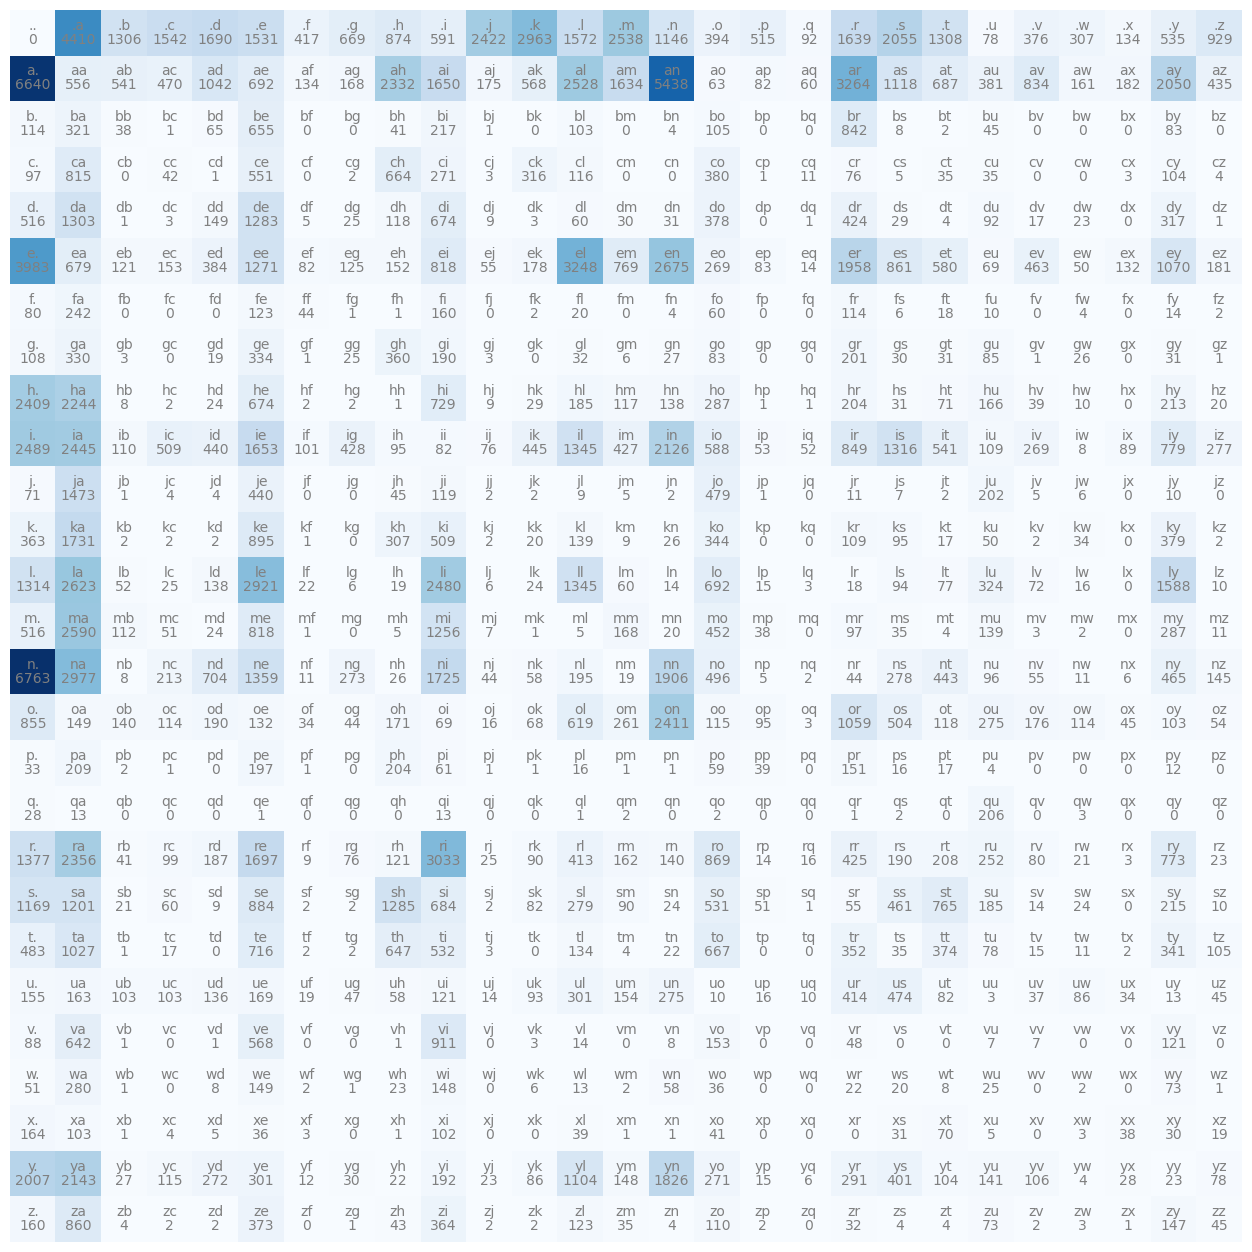

In [86]:
import torch

a = torch.zeros((3,5), dtype=torch.int32) 


N = torch.zeros((27,27), dtype=torch.int32)
for w in words[:]:
    chs = ['.'] + list(w)+ ['.']
    for ch1,ch2 in zip(chs, chs[1:]):
        nidx1 = stoi[ch1]
        nidx2 = stoi[ch2]
        N[nidx1,nidx2]+=1
N
itos = {i:s for s,i in stoi.items()}
print(N[0])
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')

for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j,i,chstr,ha="center", va="bottom", color = 'gray')
        plt.text(j,i,N[i,j].item(), ha="center", va="top", color = 'gray')
plt.axis('off')
plt.show()

In [87]:
P = (N+1).float()
P/=P.sum(1,keepdim=True)
g = torch.Generator().manual_seed(2147483647)

ix = 0
for i in range(20):
  word = ''
  while True:
    p = P[ix]
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    word+=itos[ix]
    if ix == 0:
      break
  print(word)




cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.


In [88]:
totalLLH = 0
n = 0
for w in words[:3]:
    chs = ["."]+list(w)+["."]
    for ch1, ch2 in zip(chs, chs[1:]):
        n+=1
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        print(f'{ch1}{ch2}: {prob:.4f} {logprob: .4f}')
        print(f'NLL: {-1*logprob}')
        totalLLH+= (-1*logprob)
print(f'NLL Total = {totalLLH}')
print(f' avg NLL {totalLLH/n}')

.e: 0.0478 -3.0410
NLL: 3.0410351753234863
em: 0.0377 -3.2793
NLL: 3.2793476581573486
mm: 0.0253 -3.6753
NLL: 3.6753265857696533
ma: 0.3885 -0.9454
NLL: 0.9454260468482971
a.: 0.1958 -1.6305
NLL: 1.6305063962936401
.o: 0.0123 -4.3965
NLL: 4.396478652954102
ol: 0.0779 -2.5526
NLL: 2.5525903701782227
li: 0.1774 -1.7293
NLL: 1.7293236255645752
iv: 0.0152 -4.1845
NLL: 4.184478759765625
vi: 0.3508 -1.0476
NLL: 1.0476267337799072
ia: 0.1380 -1.9807
NLL: 1.9806911945343018
a.: 0.1958 -1.6305
NLL: 1.6305063962936401
.a: 0.1376 -1.9835
NLL: 1.983507752418518
av: 0.0246 -3.7041
NLL: 3.704092502593994
va: 0.2473 -1.3971
NLL: 1.3971220254898071
a.: 0.1958 -1.6305
NLL: 1.6305063962936401
NLL Total = 38.80856704711914
 avg NLL 2.4255354404449463


In [89]:
xs, ys = [],[]
n = 0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
        n += 1
xs = torch.tensor(xs)
ys = torch.tensor(ys)
bigramCount = xs.nelement()
print("num of training bigrams: ", n)


num of training bigrams:  228146


In [94]:
import torch.nn.functional as F
W = torch.randn((27,27), generator=g, requires_grad=True)

for i in range(2000):
#forward pass
    xenc = F.one_hot(xs,num_classes=27).float()
    logits = xenc @ W
    counts = logits.exp()
    probs = counts/counts.sum(1,keepdim=True)
    loss = -probs[torch.arange(bigramCount), ys].log().mean()
    print("loss: ",loss)
    #backward pass
    W.grad = None # set gradient to zero
    loss.backward()
    W.data  += -50*W.grad




loss:  tensor(3.8211, grad_fn=<NegBackward0>)
loss:  tensor(3.4093, grad_fn=<NegBackward0>)
loss:  tensor(3.1766, grad_fn=<NegBackward0>)
loss:  tensor(3.0317, grad_fn=<NegBackward0>)
loss:  tensor(2.9310, grad_fn=<NegBackward0>)
loss:  tensor(2.8562, grad_fn=<NegBackward0>)
loss:  tensor(2.7996, grad_fn=<NegBackward0>)
loss:  tensor(2.7560, grad_fn=<NegBackward0>)
loss:  tensor(2.7217, grad_fn=<NegBackward0>)
loss:  tensor(2.6941, grad_fn=<NegBackward0>)
loss:  tensor(2.6715, grad_fn=<NegBackward0>)
loss:  tensor(2.6527, grad_fn=<NegBackward0>)
loss:  tensor(2.6369, grad_fn=<NegBackward0>)
loss:  tensor(2.6234, grad_fn=<NegBackward0>)
loss:  tensor(2.6118, grad_fn=<NegBackward0>)
loss:  tensor(2.6016, grad_fn=<NegBackward0>)
loss:  tensor(2.5926, grad_fn=<NegBackward0>)
loss:  tensor(2.5846, grad_fn=<NegBackward0>)
loss:  tensor(2.5775, grad_fn=<NegBackward0>)
loss:  tensor(2.5711, grad_fn=<NegBackward0>)
loss:  tensor(2.5653, grad_fn=<NegBackward0>)
loss:  tensor(2.5600, grad_fn=<Neg

In [91]:
#SUMMARY FOR NN:
nlls = torch.zeros(5)
for i in range(5):
    x = xs[i].item() # input
    y = ys[i].item() # label(training output)
    print('---')
    print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x} {y})')
    print('input to the neural net:', x)
    print('outputs probs of the neural net', probs[i])
    print('label (training character):', y)
    p = probs [i, y]
    print('probablity assigned to the correct label by the neural net:', p.item())
    logp = torch.log(p)
    print('log likelihood;', logp.item())
    nll = -logp
    print('negative log likelihood:', nll.item())
    nlls[i] = nll
print('==========')
print('average negative log likelihood, i.e. loss=', nlls.mean().item())




---
bigram example 1: .e (indexes 0 5)
input to the neural net: 0
outputs probs of the neural net tensor([0.0298, 0.0983, 0.0073, 0.0189, 0.0445, 0.0089, 0.0455, 0.0032, 0.0245,
        0.0424, 0.0274, 0.0175, 0.0159, 0.0051, 0.1206, 0.0912, 0.0665, 0.0051,
        0.0133, 0.0358, 0.0376, 0.0580, 0.0591, 0.0218, 0.0288, 0.0555, 0.0175],
       grad_fn=<SelectBackward0>)
label (training character): 5
probablity assigned to the correct label by the neural net: 0.00886445865035057
log likelihood; -4.725705623626709
negative log likelihood: 4.725705623626709
---
bigram example 2: em (indexes 5 13)
input to the neural net: 5
outputs probs of the neural net tensor([0.0123, 0.1038, 0.0051, 0.0136, 0.0094, 0.0406, 0.0682, 0.0390, 0.0094,
        0.0184, 0.0586, 0.0524, 0.0701, 0.0360, 0.0230, 0.0611, 0.0023, 0.0747,
        0.0669, 0.0557, 0.0047, 0.0195, 0.0213, 0.0234, 0.0048, 0.0547, 0.0510],
       grad_fn=<SelectBackward0>)
label (training character): 13
probablity assigned to the correct

In [106]:
ix = 0
for i in range(20):
    word = ''
    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc@W
        counts = logits.exp()
        probs = counts/counts.sum(1, keepdim=True)
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        word+=itos[ix]
        if ix == 0:
            break
    print(word)

asylio.
lesh.
reis.
fizarar.
la.
sh.
zalin.
n.
bazirel.
kemquza.
hilendy.
mea.
mean.
ce.
e.
ce.
ga.
sitemieia.
anta.
ssosazy.
